In [8]:
from itertools import product
from typing import Any, Dict, Iterable
from datetime import datetime

from sklearn.metrics import mean_squared_error
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN
import pandas as pd
import numpy as np
import os
import re
import tensorflow as tf
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

In [9]:
NUM_SAMPLES = 300

config_base = load_config('configs/default.yaml')

fixed_points = {
        (0.0, 0.0) : "unstable", 
    } 
config = config_base
config["activation"] = "swish"
config["N_hidden"] = 4
config["N_neurons"] = 50
config["N_epochs"] = 25000
config["T"] = 12.5
config["freq_save"] = 0


version : default
seed : 1
mu : 1.0
x0 : 0.5
x_t0 : 0.0
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01


In [11]:
plt.rcParams.update({'font.size': 14,
                     'axes.titlepad': 10,
                     'axes.titlesize': 14,
                     'axes.labelsize': 12,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })

*** PINN build & initialized ***


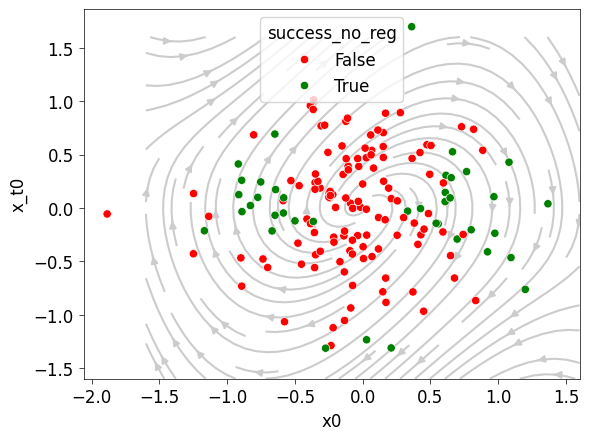

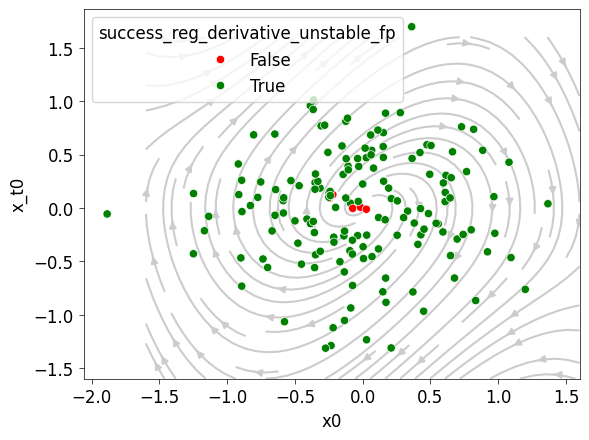

In [6]:
PINN = PhysicsInformedNN(config=config)

results_table = pd.read_csv("visual_results_T_12_5.csv")
results_table["x0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[0])
results_table["x_t0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}

xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-1.6, 1.6, n_arrows)
x_t = np.linspace(-1.6, 1.6, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dx_t] = PINN.data.diff_equations(t, Y)
x, x_t = XX.flatten(), YY.flatten()


plt.figure()
# plt.quiver(x, x_t, dx, dx_t, color='0.5')
plt.streamplot(XX, YY, dx.reshape(XX.shape), dx_t.reshape(YY.shape), color='0.8', zorder=0)
sns.scatterplot(data=results_table, x="x0", y="x_t0", hue="success_no_reg", palette=colors)
plt.show()


plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dx_t.reshape(YY.shape), color='0.8', zorder=0)
sns.scatterplot(data=results_table, x="x0", y="x_t0", hue="success_reg_derivative_unstable_fp", palette=colors)
plt.show()

version : default
seed : 1
mu : 1.0
x0 : 0.5
x_t0 : 0.0
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01
*** PINN build & initialized ***


/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***


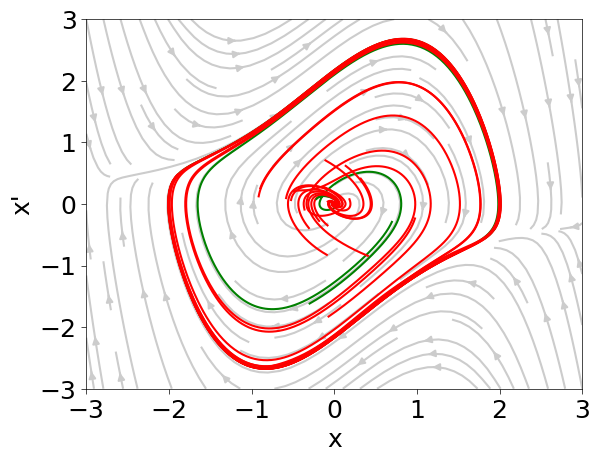

*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***


<Figure size 640x480 with 0 Axes>

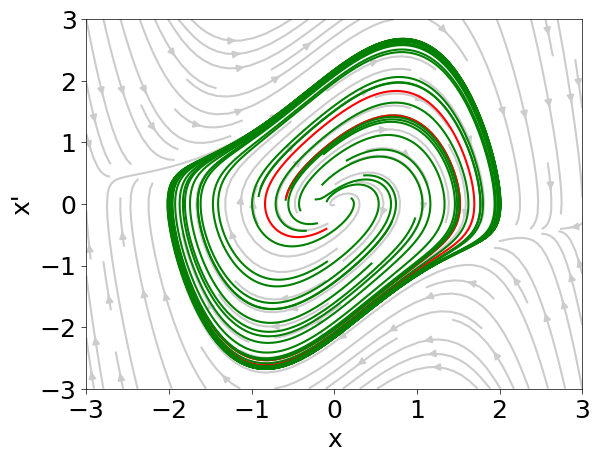

<Figure size 640x480 with 0 Axes>

In [ ]:
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN


config = load_config('configs/default.yaml')
config["T"] = 12.5
PINN = PhysicsInformedNN(config)

results_table = pd.read_csv("visual_results_T_12_5.csv").iloc[0:20]

results_table["x0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[0])
results_table["x_t0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}
xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-3, 3, n_arrows)
x_t = np.linspace(-3, 3, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()

plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(PINN.log_path.joinpath(f"models/visualization_experiments_T_12_5/no_reg/run_{i}.pkl"))
    t_line, x_true, x_t_true = PINN.data.reference()
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)
    color = 'green' if results_table["success_no_reg"].iloc[i] else "red"
    plt.plot(x_pred, x_t_pred, color=color)
    plt.xlabel("x", fontsize=18)
    plt.ylabel("x\'", fontsize=18)
plt.show()
plt.savefig("van_der_pol_no_reg.pdf", format="pdf")




plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(f"logs/models/visualization_experiments_T_12_5/reg_derivative_unstable_fp/run_{i}.pkl")
    t_line, x_true, x_t_true = PINN.data.reference()
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)
    color = 'green' if results_table["success_reg_derivative_unstable_fp"].iloc[i] else "red"
    plt.plot(x_pred, x_t_pred, color=color)
    plt.xlabel("x", fontsize=18)
    plt.ylabel("x\'", fontsize=18)
plt.show()
plt.savefig("van_der_pol_reg.pdf", format="pdf")


version : default
seed : 1
alpha : -1.0
beta : 1.0
delta : 1.0
x0 : 0.01
x_t0 : 0.0
T : 12.5
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01
*** PINN build & initialized ***
*** PINN build & initialized ***


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***


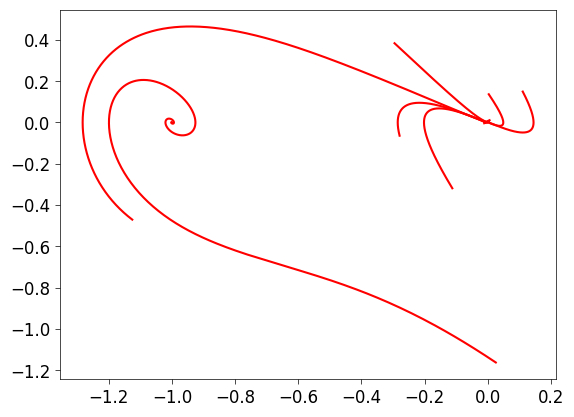

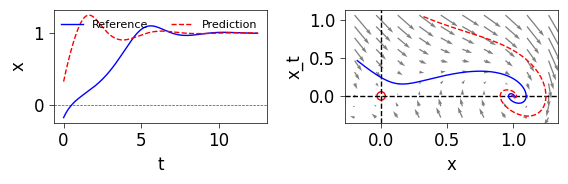

In [13]:
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN
from model.plots import unforced_duffing_dynamics


config = load_config('configs/default.yaml')
config["T"] = 12.5
PINN = PhysicsInformedNN(config)

results_table = pd.read_csv("visual_results.csv")
results_table["x0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[0])
results_table["x_t0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}
xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-1.5, 1.5, n_arrows)
x_t = np.linspace(-1.5, 1.5, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()

plt.figure()


for i in range(results_table.shape[0]):
    if results_table["success_no_reg"].iloc[i]:
        continue
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(PINN.log_path.joinpath(f"models/visualization_experiments/no_reg/run_{i}.pkl"))
    t_line, x_true, x_t_true = PINN.data.reference()
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)
    if (tf.reduce_mean(x_pred[-5]) - 0.0) > 0.01:
        unforced_duffing_dynamics(PINN)
        break
    color = 'green' if results_table["success_no_reg"].iloc[i] else "red"
    plt.plot(x_pred, x_t_pred, color=color)

version : default
seed : 1
mu : 1.0
x0 : 0.5
x_t0 : 0.0
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01
*** PINN build & initialized ***


/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN b

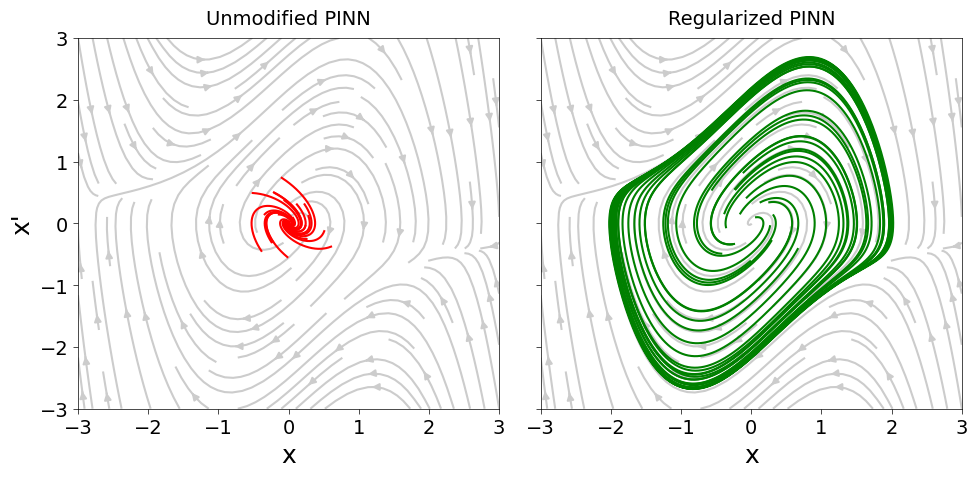

In [15]:
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN


config = load_config('configs/default.yaml')
config["T"] = 12.5
PINN = PhysicsInformedNN(config)

results_table = pd.read_csv("visual_results_T_15.csv").iloc[0:20]
results_table["x0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[0])
results_table["x_t0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}
xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-3, 3, n_arrows)
x_t = np.linspace(-3, 3, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()

# plt.figure()
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))

axes[0].streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(PINN.log_path.joinpath(f"models/visualization_experiments_T_15/no_reg/run_{i}.pkl"))
    t_line, x_true, x_t_true = PINN.data.reference()
    # get PINN prediction
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)

    color = 'green' if results_table["success_no_reg"].iloc[i] else "red"
    axes[0].plot(x_pred, x_t_pred, color=color)
    axes[0].set_xlabel("x", fontsize=18)
    axes[0].set_ylabel("x'", fontsize=18)

axes[1].streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(f"logs/models/visualization_experiments_T_15/reg_derivative_unstable_fp/run_{i}.pkl")
    t_line, x_true, x_t_true = PINN.data.reference()
    # get PINN prediction
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)
    color = 'green' if results_table["success_reg_derivative_unstable_fp"].iloc[i] else "red"
    axes[1].plot(x_pred, x_t_pred, color=color)
    axes[1].set_xlabel("x", fontsize=18)
    # plt.ylabel("y", fontsize=18)
    # plt.yticks([])

# plt.show()

axes[0].set_title("Unmodified PINN")
axes[1].set_title("Regularized PINN")
plt.tight_layout()
plt.savefig("van_der_pol_reg_test.pdf", format="pdf")